### Función de autocorrelación

Observar partrones característicos de la serie de tiempo dependiendo si la serie contiene tendencia o estacionalidad

*"El conjunto de **coeficientes de autocorrelación** que resultan de comparar la serie consigo misma para diferentes valores de 'lags'"*

In [13]:
import pandas as pd
import matplotlib.pyplot as plt


In [12]:
datos = {'ventas' : [100, 120, 130, 150, 160, 170, 180, 190, 210, 220, 230, 250,
                    110, 125, 135, 155, 165, 175, 185, 195, 215, 225, 235, 255,
                    115, 130, 140, 160, 170, 180, 190, 200, 220, 230, 240, 260]}
indice = pd.date_range(start='2018-01-01',
                        periods = 36,
                        freq = 'ME')
df = pd.DataFrame(datos, index= indice)
df.head()

,ventas
2018-01-31,100
2018-02-28,120
2018-03-31,130
2018-04-30,150
2018-05-31,160


Text(0.5, 0, 'Mes')

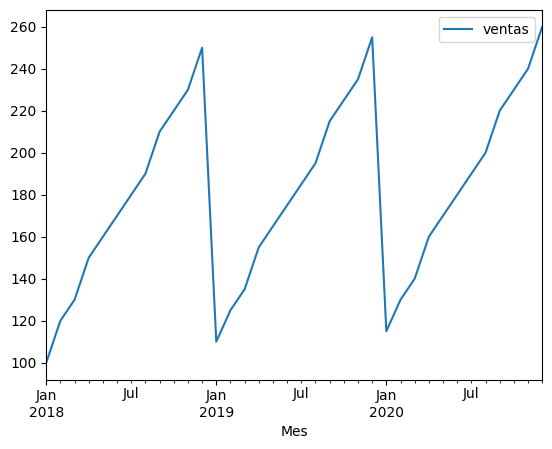

In [16]:
ax = df.plot()
ax.set_xlabel('Mes')

Comparación de la serie consigomisma a traves de corerlación

Cuando no se tienen lags, el coeficiente de autocorrelación es 1, pero al desplazar la serie con lags, dicho coeficiente va a ir disminuyendo gradualmente

coef lag 0: 0.9999999999999999
coef lag 1: 0.6464801172040319
coef lag 2: 0.34485493354399543
coef lag 3: 0.03742702705182432
coef lag 12: 0.999775663044765


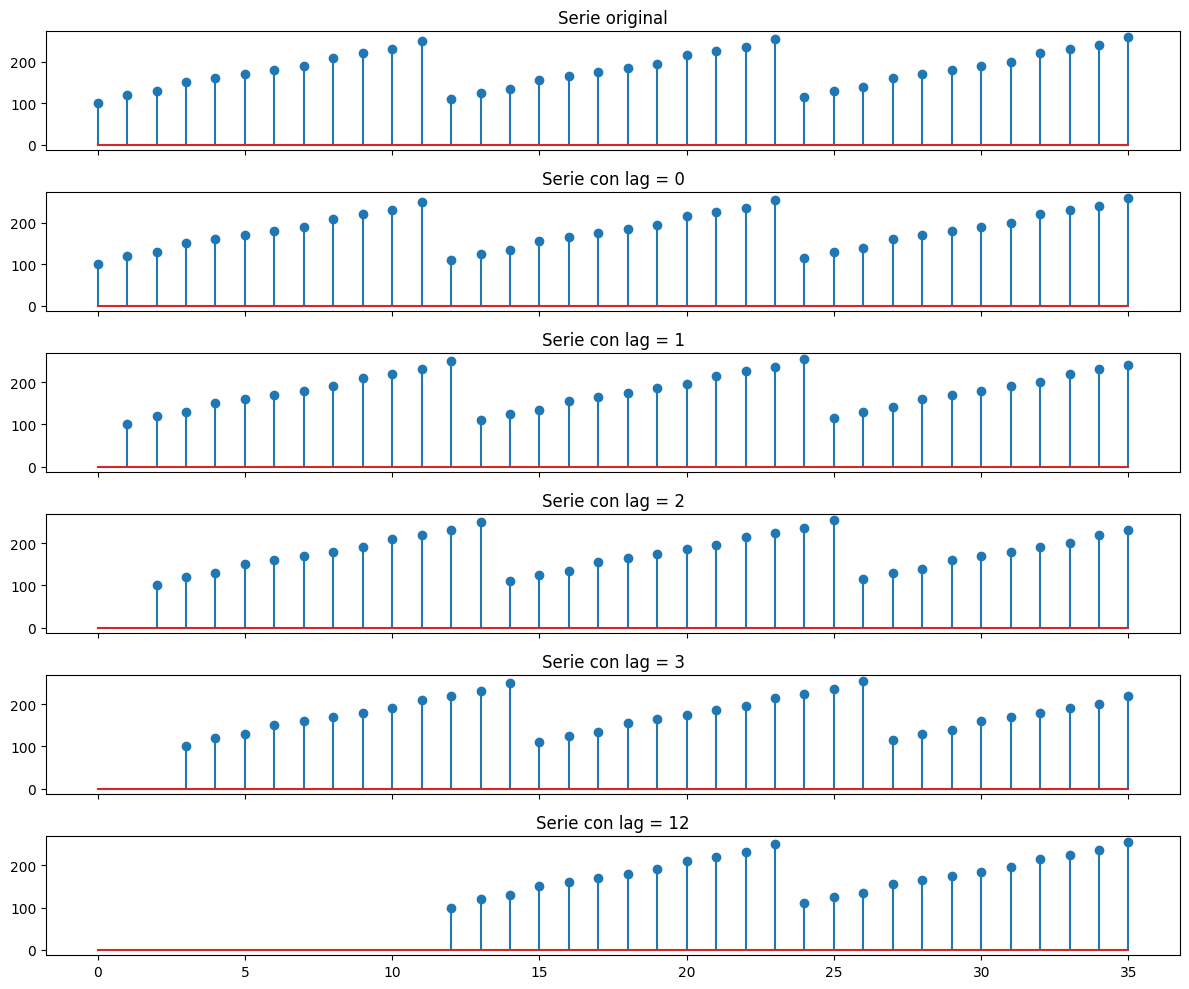

In [36]:
fig, ax = plt.subplots(6, 1, figsize = (12,10), sharex = True)

ax[0].stem(df['ventas'])
ax[1].stem(df['ventas'])
ax[2].stem(df['ventas'].shift(1))
ax[3].stem(df['ventas'].shift(2))
ax[4].stem(df['ventas'].shift(3))
ax[5].stem(df['ventas'].shift(12))

ax[0].set_title('Serie original')
ax[1].set_title('Serie con lag = 0')
ax[2].set_title('Serie con lag = 1')
ax[3].set_title('Serie con lag = 2')
ax[4].set_title('Serie con lag = 3')
ax[5].set_title('Serie con lag = 12')

fig.tight_layout()
corr_lag_0 = df['ventas'].corr(df['ventas'].shift(0))
corr_lag_1 = df['ventas'].corr(df['ventas'].shift(1))
corr_lag_2 = df['ventas'].corr(df['ventas'].shift(2))
corr_lag_3 = df['ventas'].corr(df['ventas'].shift(3))
corr_lag_12 = df['ventas'].corr(df['ventas'].shift(12))

print(f'coef lag 0: {corr_lag_0}')
print(f'coef lag 1: {corr_lag_1}')
print(f'coef lag 2: {corr_lag_2}')
print(f'coef lag 3: {corr_lag_3}')
print(f'coef lag 12: {corr_lag_12}')

La frecuencia de muestreo es semanal, es una serie estacional y la periodicidad es anual. Por esa periodicidad anual es que cuando hay un lag de 12, la serie tiene un coeficiente de autocorrelación cercano a 1

### Función de autocorrelación

> Es un conjunto de coeficientes de autocorrelación que se obtienen de comparar la serie de tiempo consigomisma para diferentes lags.

In [31]:
import statsmodels.graphics.tsaplots as tsaplots

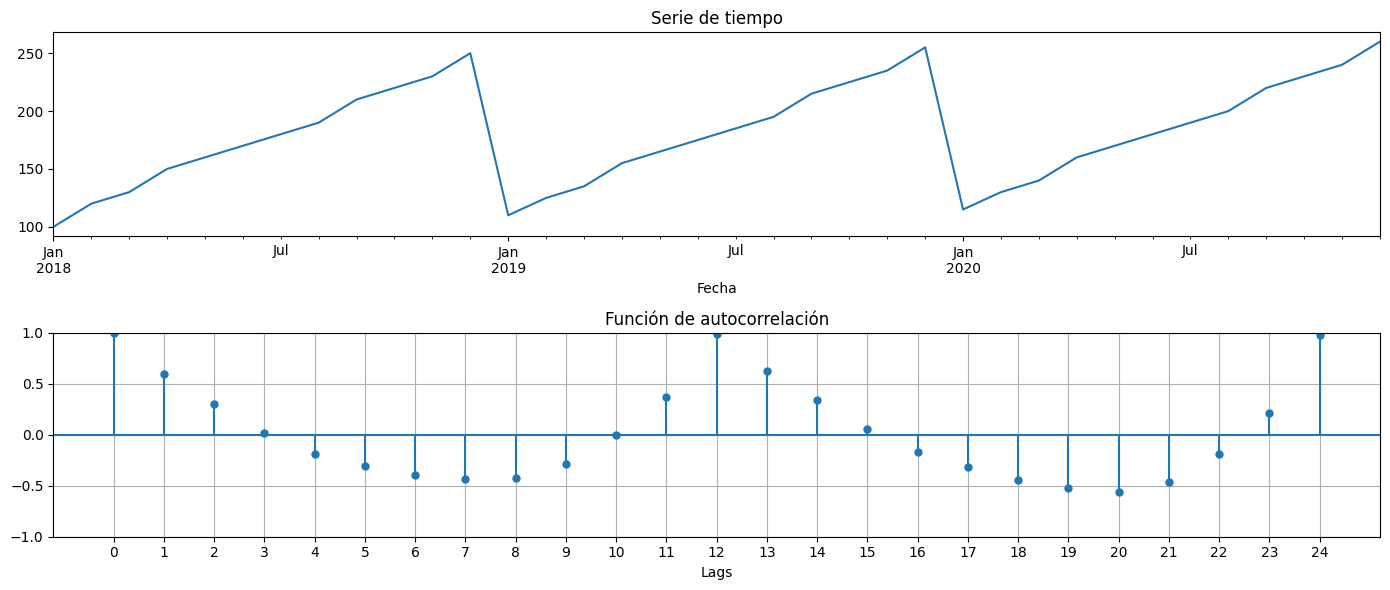

In [34]:
fig, ax = plt.subplots(2, 1, figsize = (14, 6))

df['ventas'].plot(ax = ax[0])
ax[0].set_title('Serie de tiempo')
ax[0].set_xlabel('Fecha')

LAGS = 24
tsaplots.plot_acf(df['ventas'].to_numpy(),
                adjusted = True,
                lags = LAGS, 
                alpha = None,
                bartlett_confint = False,
                ax = ax[1])
ax[1].set_title('Función de autocorrelación')
ax[1].set_xlabel('Lags')
ax[1].set_xticks(range(0, LAGS+1))
ax[1].grid()
fig.tight_layout()


### Significado de la función de autocorrelación

Se puede obtener una interpretación para series:

1. Estacionales
2. Tendencia
3. Ruido

In [39]:
series = pd.read_csv('datos/series_est_tend_ruido.csv',
                        parse_dates=['fecha'],
                        index_col='fecha')
series.head()

,estacional,tendencia,ruido
fecha,,,
2018-01-31,100,260,84.707895
2018-02-28,120,272,83.828078
2018-03-31,130,243,79.130258
2018-04-30,150,250,79.702665
2018-05-31,160,232,91.363245


* Serie estacional con frecuencia mensual, periodicidad anual
* Serie de tendencia descendente
* Serie de ruido

<Axes: xlabel='fecha'>

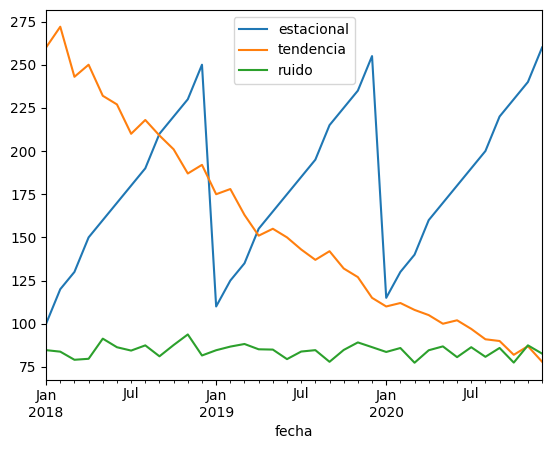

In [ ]:
series.plot()

##### Serie estacional

> Cuando una serie de tiempo es estacional, su función de autocorrelación va a presentar valores que van a ir fluctuando periódicamente entre un maximo y un minimo

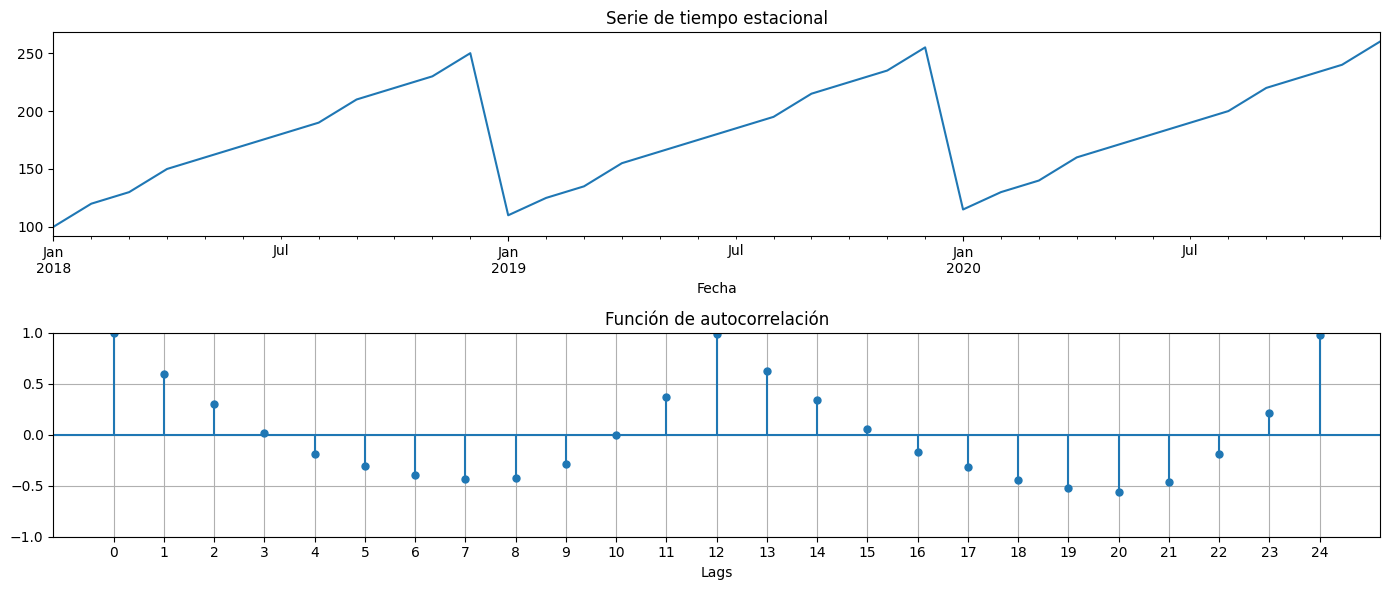

In [45]:
fig, ax = plt.subplots(2, 1, figsize = (14, 6))

series['estacional'].plot(ax = ax[0])
ax[0].set_title('Serie de tiempo estacional')
ax[0].set_xlabel('Fecha')

LAGS = 24
tsaplots.plot_acf(series['estacional'].to_numpy(),
                adjusted = True,
                lags = LAGS, 
                alpha = None,
                bartlett_confint = False,
                ax = ax[1])
ax[1].set_title('Función de autocorrelación')
ax[1].set_xlabel('Lags')
ax[1].set_xticks(range(0, LAGS+1))
ax[1].grid()
fig.tight_layout()

##### Serie con tendencia

> Cuando una serie de tiempo tiene tendencia positiva o negativa, su función de autocorrelación tendrá sus valores más altos en los lags mas bajos, e irán disminuyendo gradualmente

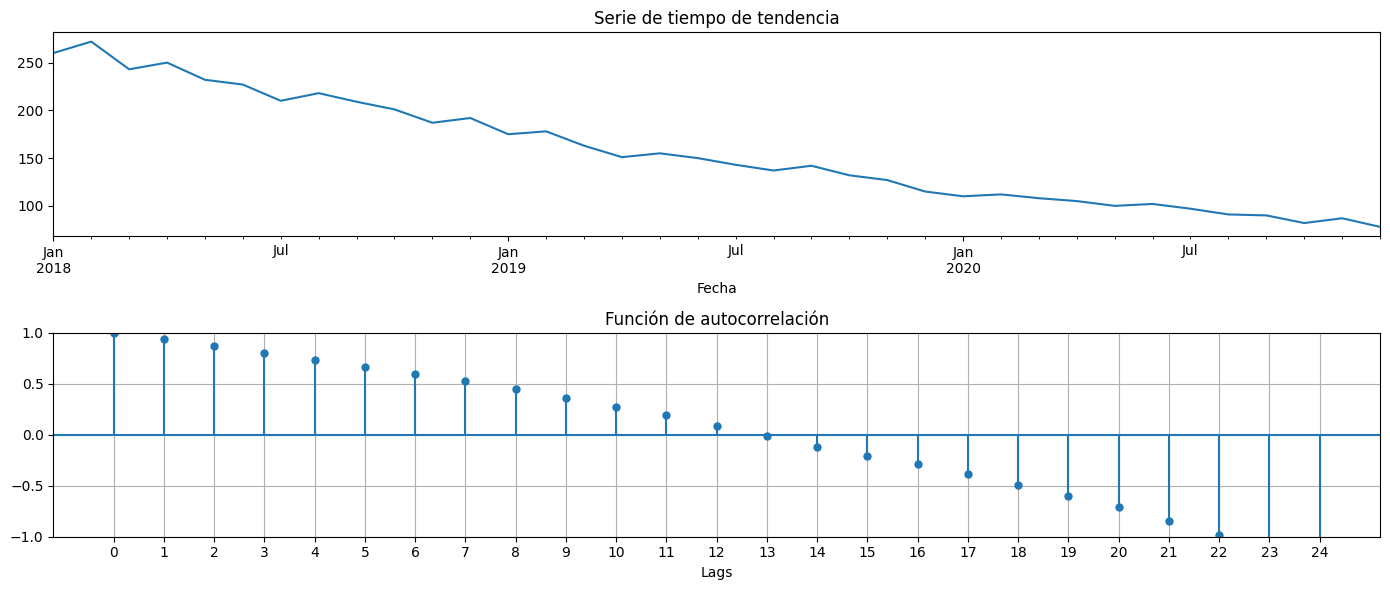

In [44]:
fig, ax = plt.subplots(2, 1, figsize = (14, 6))

series['tendencia'].plot(ax = ax[0])
ax[0].set_title('Serie de tiempo de tendencia')
ax[0].set_xlabel('Fecha')

LAGS = 24
tsaplots.plot_acf(series['tendencia'].to_numpy(),
                adjusted = True,
                lags = LAGS, 
                alpha = None,
                bartlett_confint = False,
                ax = ax[1])
ax[1].set_title('Función de autocorrelación')
ax[1].set_xlabel('Lags')
ax[1].set_xticks(range(0, LAGS+1))
ax[1].grid()
fig.tight_layout()

##### Serie de ruido

> Cuando una serie de tiempo es de ruido, la función de autocorrelación va a presentar un valor alto únicamente cuando no se tiene un lag, para los demás lags, dificilmente va a encontrar una buena correlación y por eso los coeficientes siempre van a ser bajos

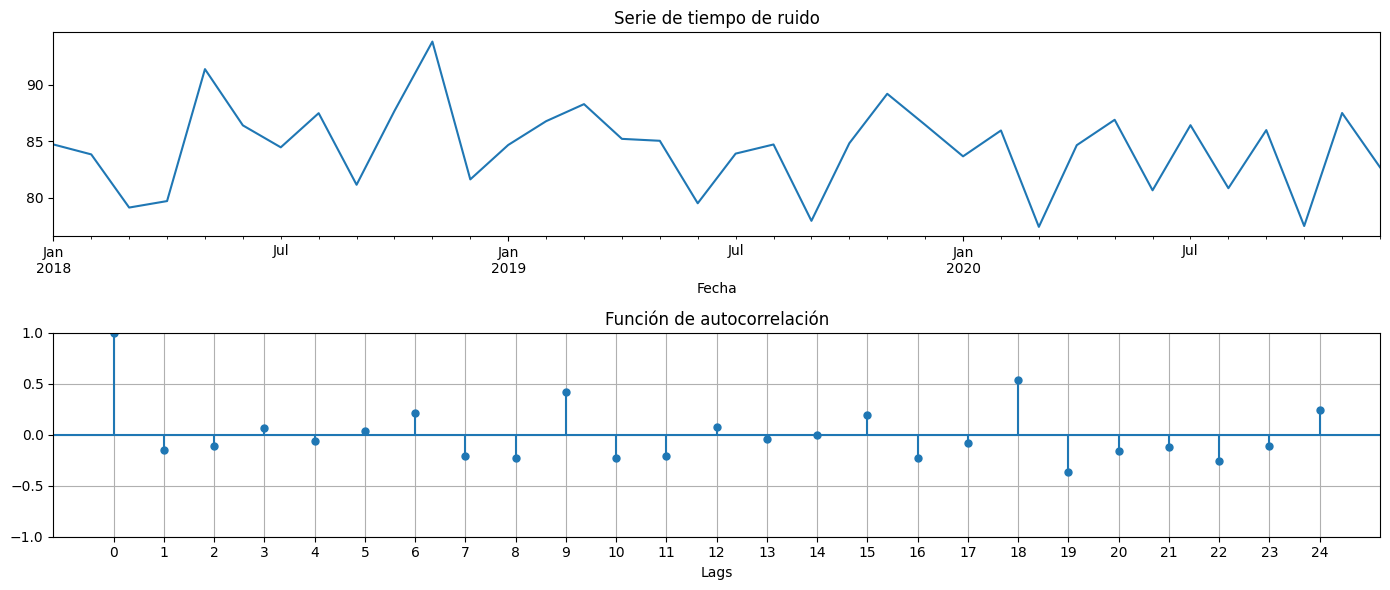

In [46]:
fig, ax = plt.subplots(2, 1, figsize = (14, 6))

series['ruido'].plot(ax = ax[0])
ax[0].set_title('Serie de tiempo de ruido')
ax[0].set_xlabel('Fecha')

LAGS = 24
tsaplots.plot_acf(series['ruido'].to_numpy(),
                adjusted = True,
                lags = LAGS, 
                alpha = None,
                bartlett_confint = False,
                ax = ax[1])
ax[1].set_title('Función de autocorrelación')
ax[1].set_xlabel('Lags')
ax[1].set_xticks(range(0, LAGS+1))
ax[1].grid()
fig.tight_layout()

### Intervalo de confianza

> Es el nivel de certeza que tenemos de que nuestros datos se van a encontrar dentro de un rango determinado de 

Cuando un valor está fuera del intervalo de confianza se considera que es excepcionalemente grande. En este caso 1, 12, y 24. Justamente coinciden con la periodicidad de esta serie de tiempo

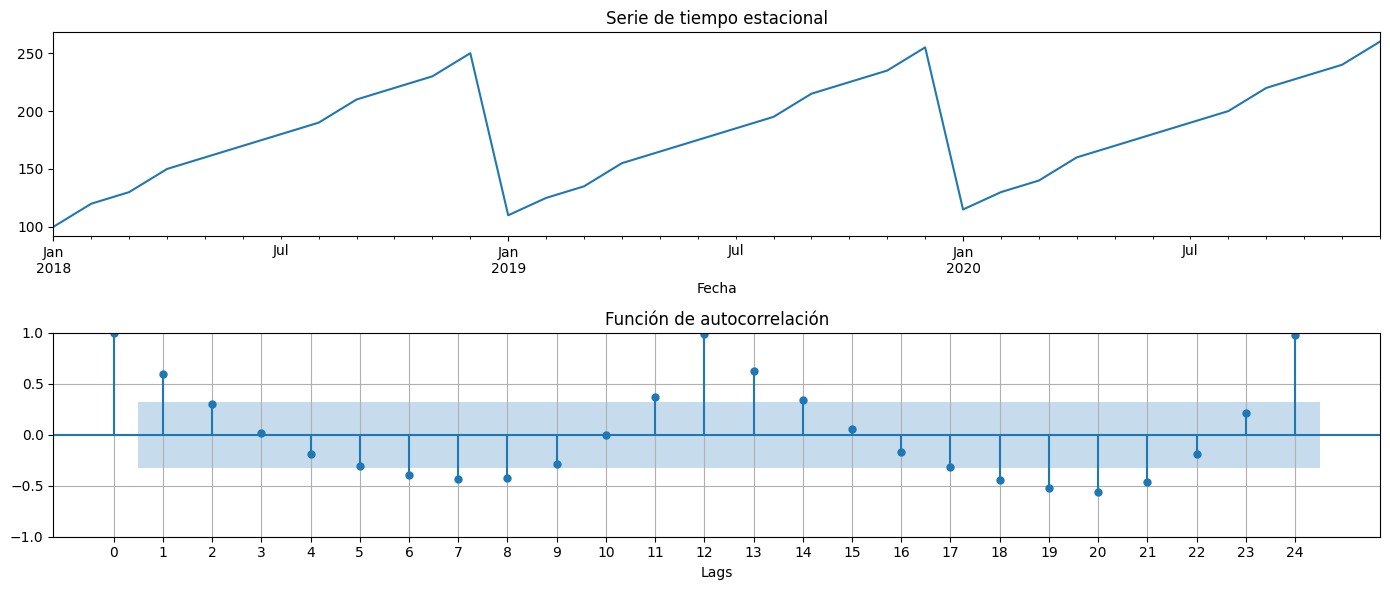

In [48]:
fig, ax = plt.subplots(2, 1, figsize = (14, 6))

series['estacional'].plot(ax = ax[0])
ax[0].set_title('Serie de tiempo estacional')
ax[0].set_xlabel('Fecha')

LAGS = 24
tsaplots.plot_acf(series['estacional'].to_numpy(),
                adjusted = True,
                lags = LAGS, 
                alpha = 0.05,
                bartlett_confint = False,
                ax = ax[1])
ax[1].set_title('Función de autocorrelación')
ax[1].set_xlabel('Lags')
ax[1].set_xticks(range(0, LAGS+1))
ax[1].grid()
fig.tight_layout()

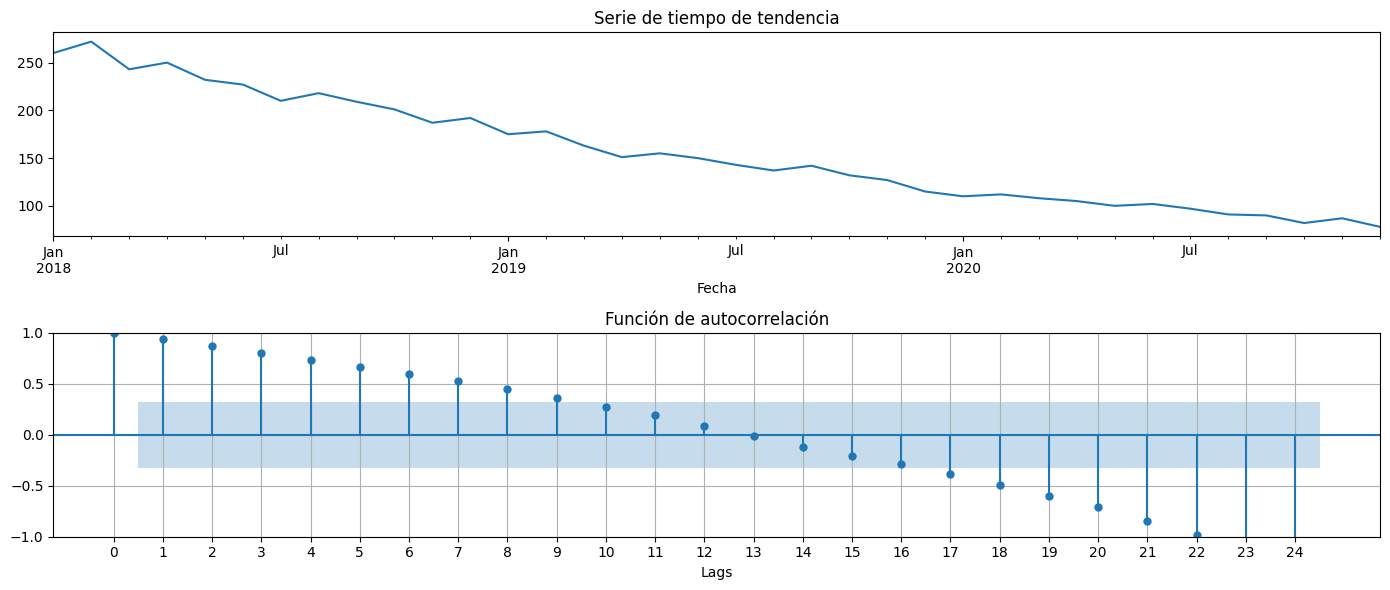

In [49]:
fig, ax = plt.subplots(2, 1, figsize = (14, 6))

series['tendencia'].plot(ax = ax[0])
ax[0].set_title('Serie de tiempo de tendencia')
ax[0].set_xlabel('Fecha')

LAGS = 24
tsaplots.plot_acf(series['tendencia'].to_numpy(),
                adjusted = True,
                lags = LAGS, 
                alpha = 0.05,
                bartlett_confint = False,
                ax = ax[1])
ax[1].set_title('Función de autocorrelación')
ax[1].set_xlabel('Lags')
ax[1].set_xticks(range(0, LAGS+1))
ax[1].grid()
fig.tight_layout()

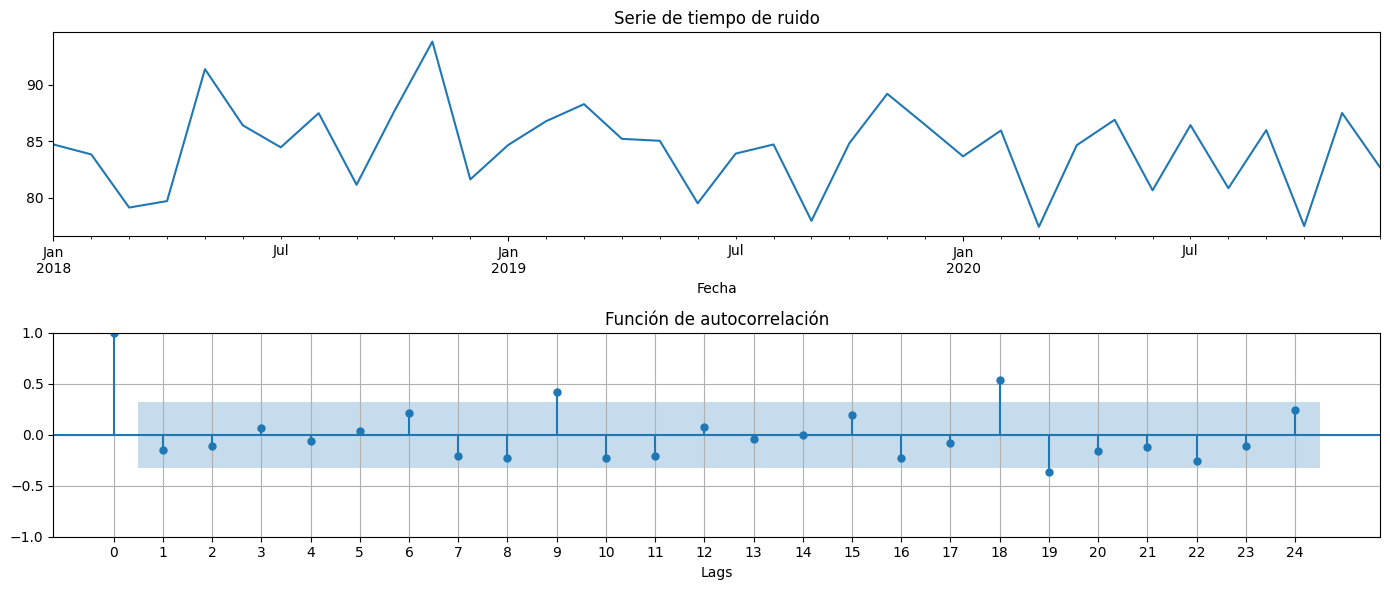

In [52]:
fig, ax = plt.subplots(2, 1, figsize = (14, 6))

series['ruido'].plot(ax = ax[0])
ax[0].set_title('Serie de tiempo de ruido')
ax[0].set_xlabel('Fecha')

LAGS = 24
tsaplots.plot_acf(series['ruido'].to_numpy(),
                adjusted = True,
                lags = LAGS, 
                alpha = 0.05,
                bartlett_confint = False,
                ax = ax[1])
ax[1].set_title('Función de autocorrelación')
ax[1].set_xlabel('Lags')
ax[1].set_xticks(range(0, LAGS+1))
ax[1].grid()
fig.tight_layout()

### Ejemplo

In [55]:
co2 = pd.read_csv('datos/co2.csv',
                    parse_dates=['fecha'],
                    index_col='fecha')
co2.head()

,co2
fecha,
1958-03-29,316.1
1958-04-05,317.3
1958-04-12,317.6
1958-04-19,317.5
1958-04-26,316.4


(2284, 1)


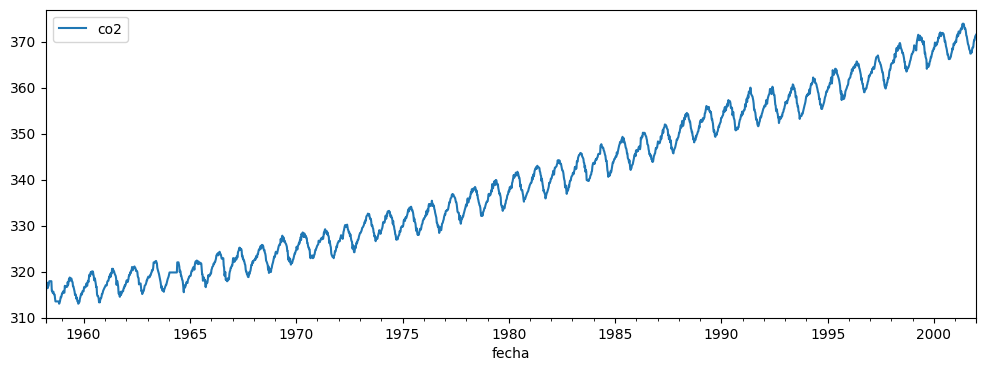

In [ ]:
co2.plot(figsize=(12,4))
# frecuencia de muestreo: Semanal
# periodicidad: anual

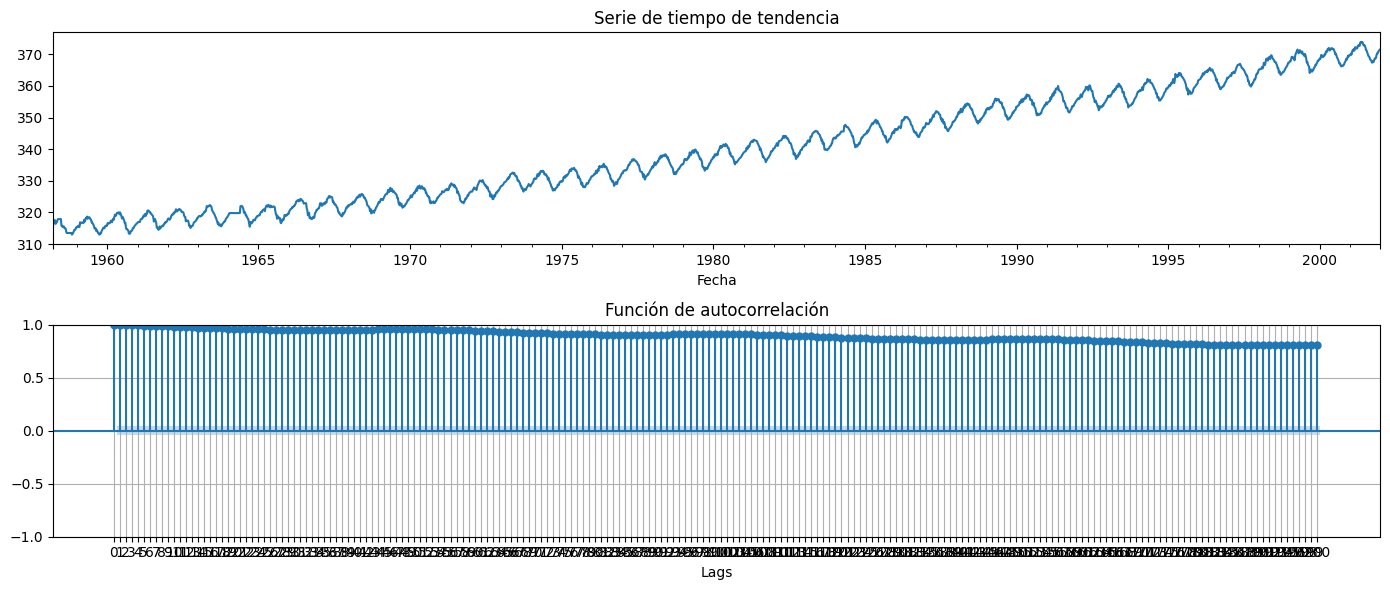

In [62]:
fig, ax = plt.subplots(2, 1, figsize = (14, 6))

co2['co2'].plot(ax = ax[0])
ax[0].set_title('Serie de tiempo de tendencia')
ax[0].set_xlabel('Fecha')

LAGS = 200
tsaplots.plot_acf(co2['co2'].to_numpy(),
                adjusted = True,
                lags = LAGS, 
                alpha = 0.05,
                bartlett_confint = False,
                ax = ax[1])
ax[1].set_title('Función de autocorrelación')
ax[1].set_xlabel('Lags')
ax[1].set_xticks(range(0, LAGS+1))
ax[1].grid()
fig.tight_layout()

Aunque es una serie de tiempo estacional, no tiene el coportamiento esperado en la función de la autocorrelación. Eso pasa porque el componente de la tendencia vence al estacional y de esta manera no se llega a apreciar. Entonces hay que descomponer la serie y observar la función de autocorrelación con la serie de comportamiento estaciónal unicamente.

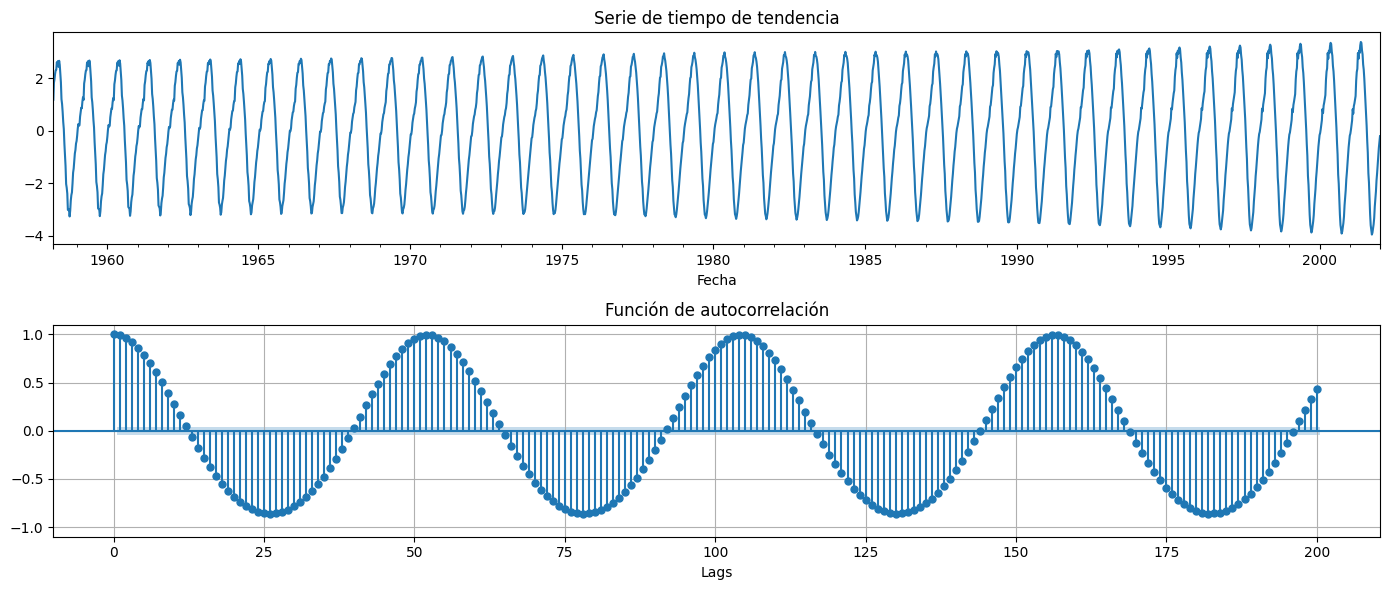

In [69]:
from statsmodels.tsa.seasonal import STL

co2_STL = STL(co2['co2'],
                    seasonal = 53).fit()
co2_seasonal = co2_STL.seasonal.to_frame('co2')

fig, ax = plt.subplots(2, 1, figsize = (14, 6))
co2_seasonal['co2'].plot(ax = ax[0])
ax[0].set_title('Serie de tiempo de tendencia')
ax[0].set_xlabel('Fecha')

LAGS = 200
tsaplots.plot_acf(co2_seasonal['co2'].to_numpy(),
                adjusted = True,
                lags = LAGS, 
                alpha = 0.05,
                bartlett_confint = False,
                ax = ax[1])
ax[1].set_title('Función de autocorrelación')
ax[1].set_xlabel('Lags')
ax[1].set_ylim([-1.1, 1.1])
ax[1].grid()
fig.tight_layout()

Cuando únicamente tenemos el componente estacional, es mas claro poder ver que cada 52 semanas se alcanza el valor más alto para los coeficientes de autocorrelación, y esto sicede ya que la periodicidad de esta serie estaciónal está marcada cada año, por lo que con una frecuencia de semanal, la estacionalidad de la serie se hace evidente.